<a href="https://colab.research.google.com/github/jamesjulius-02/k-clustering-batch/blob/main/Basic_K_Means_Clustering_on_Synthetic_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

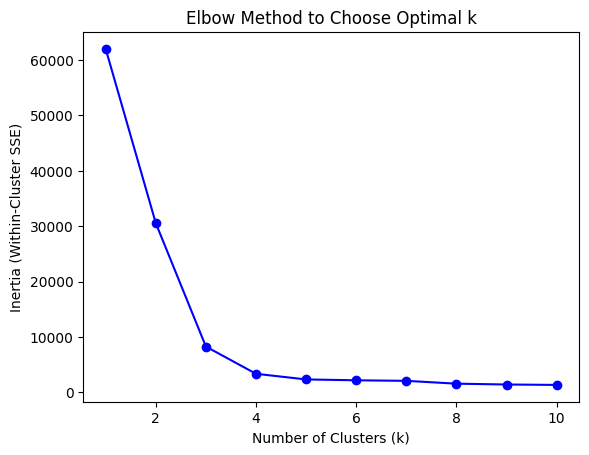

k=2 -> Silhouette Score=0.5357, Calinski-Harabasz=1027.16
k=3 -> Silhouette Score=0.7030, Calinski-Harabasz=3234.01
k=4 -> Silhouette Score=0.7091, Calinski-Harabasz=5781.73
k=5 -> Silhouette Score=0.6597, Calinski-Harabasz=6313.91
k=6 -> Silhouette Score=0.6176, Calinski-Harabasz=5415.85
k=7 -> Silhouette Score=0.5498, Calinski-Harabasz=4734.70
k=8 -> Silhouette Score=0.4770, Calinski-Harabasz=5399.75
k=9 -> Silhouette Score=0.4630, Calinski-Harabasz=5229.26
k=10 -> Silhouette Score=0.4590, Calinski-Harabasz=4908.54


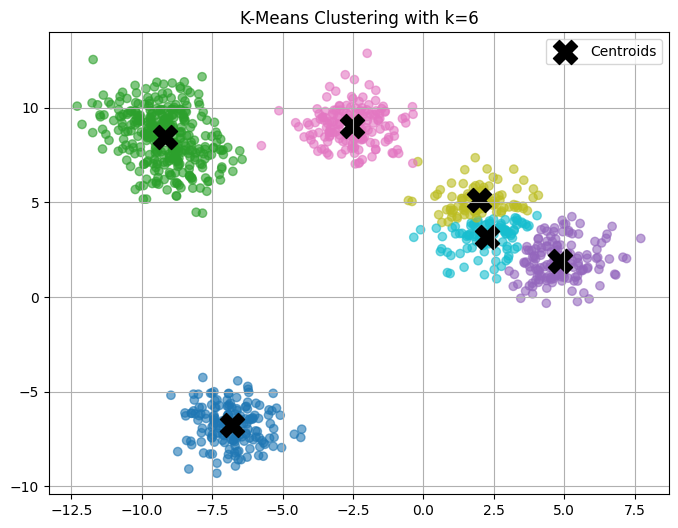

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import numpy as np

# Step 1: Generate synthetic data
X, y_true = make_blobs(n_samples=1000, centers=6, cluster_std=1.0, random_state=42)

# Step 2: Use the Elbow Method to determine optimal k
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster SSE)')
plt.title('Elbow Method to Choose Optimal k')
plt.show()

# Step 3: Silhouette & Calinski-Harabasz Score Evaluation
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    sil_score = silhouette_score(X, labels)
    calinski_score = calinski_harabasz_score(X, labels)
    print(f'k={k} -> Silhouette Score={sil_score:.4f}, Calinski-Harabasz={calinski_score:.2f}')

# Step 4: Choose best k and fit final model
best_k = 6
kmeans = KMeans(n_clusters=best_k, random_state=42)
y_kmeans = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

# Step 5: Plot final clusters
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='tab10', alpha=0.6)
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='black', marker='X', label='Centroids')
plt.title(f"K-Means Clustering with k={best_k}")
plt.legend()
plt.grid(True)
plt.show()
